In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("../bench_results_cache2/4-nbeap.csv")
df.head()

,op,size,cpu_time2withoutBubbleUp,stat,cpu_time_3withBubbleUp
0,Construct,256.0,7.754170,mean,7.21966
1,Construct,256.0,7.709080,median,7.12507
2,Construct,256.0,0.118883,stddev,0.32597
3,Construct,256.0,0.015331,cv,0.04515
4,Construct,256.0,7.967100,p90,7.38913


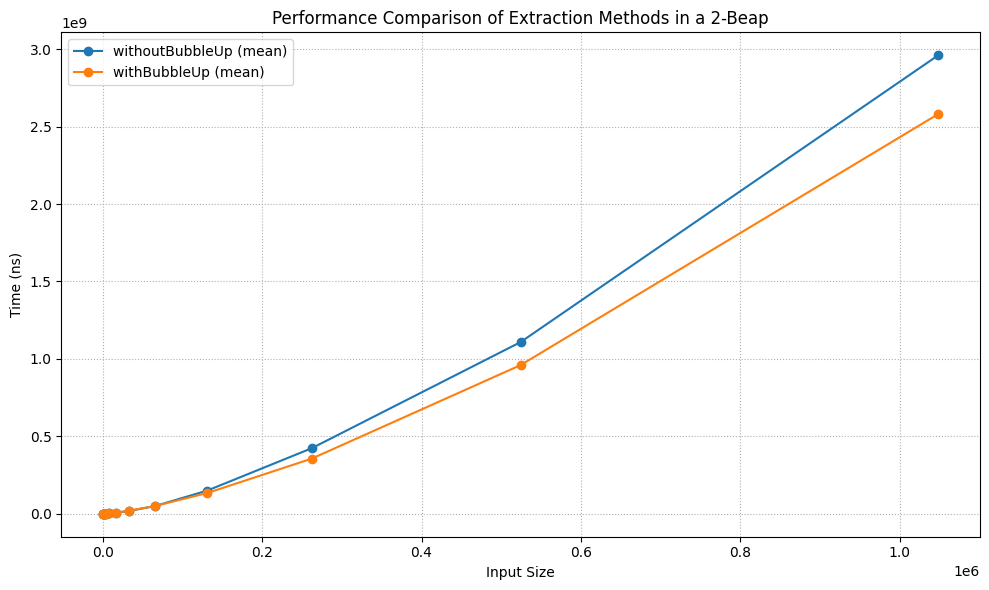

In [ ]:
labelMap = {
    "cpu_time2withoutBubbleUp": "withoutBubbleUp",
    "cpu_time_3withBubbleUp": "withBubbleUp"
}

baseCols = ["cpu_time2withoutBubbleUp", "cpu_time_3withBubbleUp"]

df_extract = df[df["op"] == "Extract"].copy()
df_extract["size"] = pd.to_numeric(df_extract["size"])

df_plot = df_extract.pivot(index="size", columns="stat", values=baseCols)
df_plot = df_plot.sort_index()

plt.figure(figsize=(10, 6))
plt.title("Performance Comparison of Extraction Methods in a 2-Beap")
plt.xlabel("Input Size")
plt.ylabel("Time (ns)")
# plt.xscale("log", base=2)
# plt.yscale("log", base=10)

x = df_plot.index.to_numpy()

for base in baseCols:
    y_mean = df_plot[(base, "median")].to_numpy()
    plt.plot(x, y_mean, marker="o", label=f"{labelMap[base]} (mean)")

plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()